<a href="https://colab.research.google.com/github/adibakhushboo/Skill-Craft-Technology-Internship/blob/main/Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'bank-marketing-dataset' dataset.
Dataset downloaded to: /kaggle/input/bank-marketing-dataset
Files in folder: ['bank.csv']

FIRST 5 ROWS
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unkno

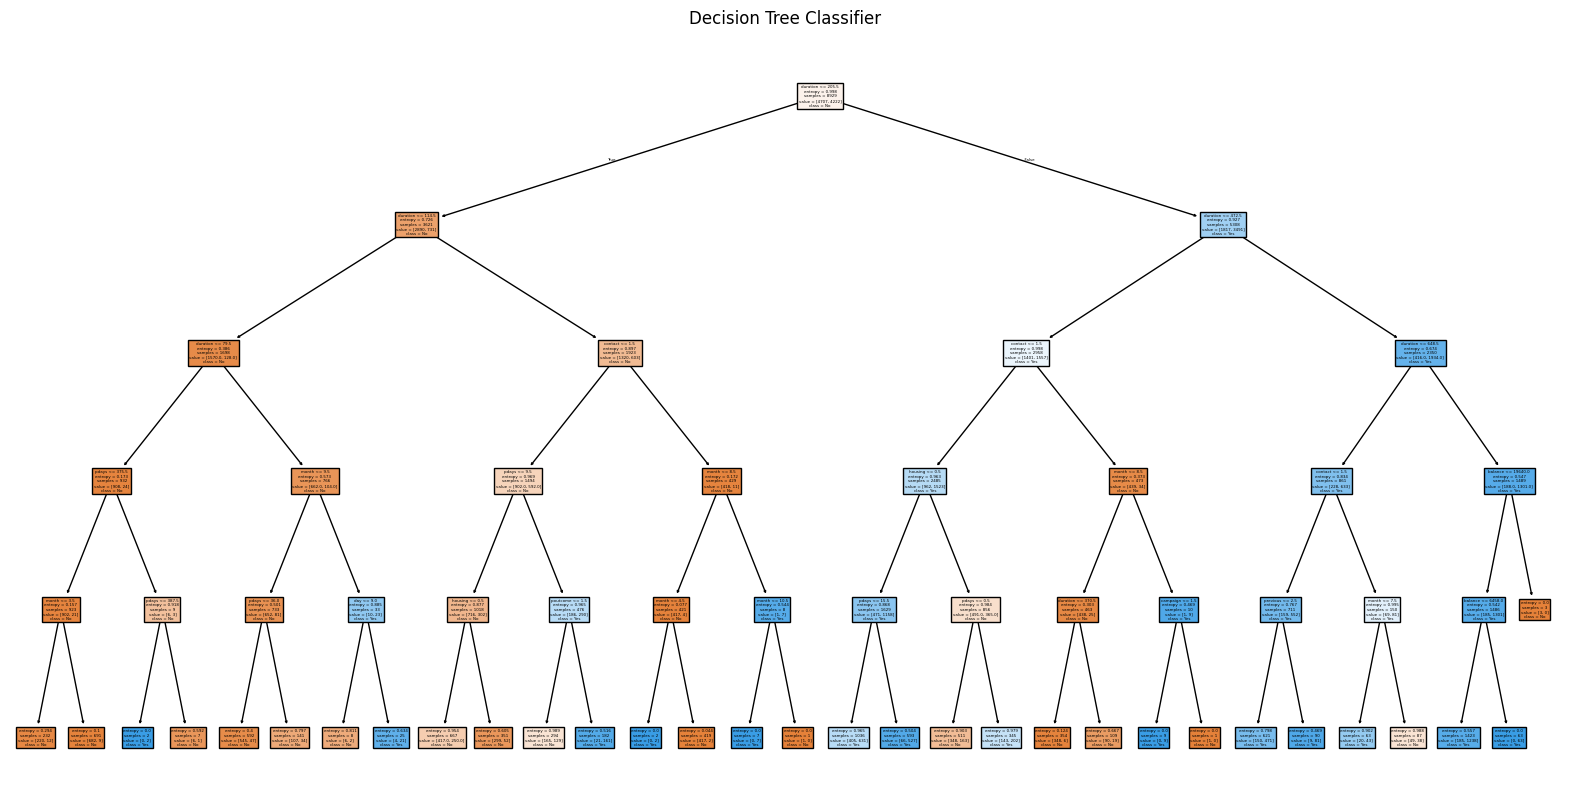


FEATURE IMPORTANCE
      Feature  Importance
11   duration    0.614413
8     contact    0.176685
13      pdays    0.081898
6     housing    0.052358
10      month    0.041292
15   poutcome    0.021629
5     balance    0.006178
14   previous    0.002208
9         day    0.001983
12   campaign    0.001357
7        loan    0.000000
4     default    0.000000
1         job    0.000000
0         age    0.000000
2     marital    0.000000
3   education    0.000000


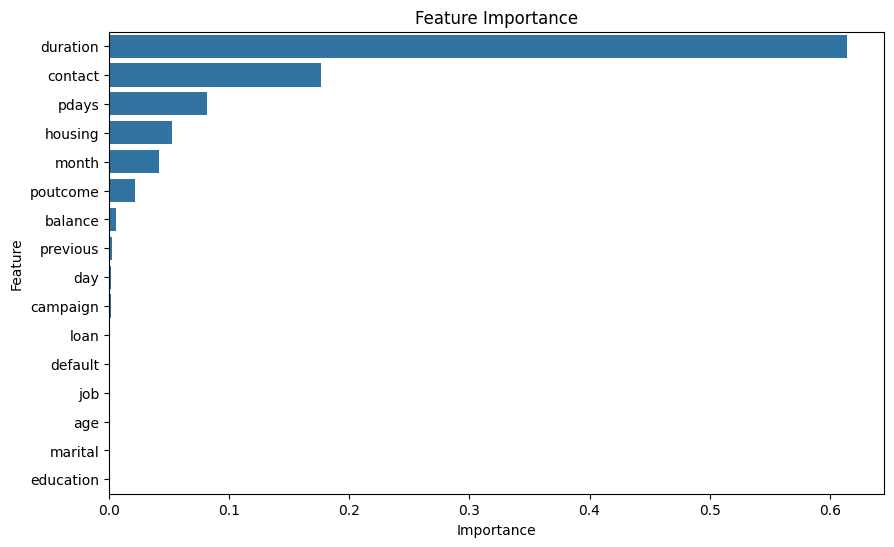


KEY OBSERVATIONS:
1. Decision Tree classified customer purchases.
2. Some features were more important.
3. Model accuracy shows prediction performance.
4. Feature importance graph shows influential variables.

CONCLUSION:
Decision Tree Classifier was built successfully
to predict customer purchases using
Bank Marketing Dataset.


In [ ]:
# TASK 03 - DECISION TREE CLASSIFIER
# BANK MARKETING DATASET

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")

print("Dataset downloaded to:", path)

files = os.listdir(path)
print("Files in folder:", files)

# Load CSV file
csv_path = os.path.join(path, "bank.csv")

df = pd.read_csv(csv_path)

print("\nFIRST 5 ROWS")
print(df.head())

print("\nCOLUMN NAMES")
print(df.columns)

print("\nDATASET INFO")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())

# Convert categorical columns into numeric values

label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])

# DEFINE FEATURES AND TARGET

# Target column = deposit

X = df.drop('deposit', axis=1)

y = df['deposit']

# SPLIT DATA

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# TRAIN DECISION TREE MODEL

model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

# MAKE PREDICTIONS

y_pred = model.predict(X_test)

# EVALUATE MODEL
accuracy = accuracy_score(y_test, y_pred)

print("\nMODEL ACCURACY:")
print(accuracy)

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

print("\nCONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred))

# =========================================================
# VISUALIZE DECISION TREE
# =========================================================

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True
)

plt.title("Decision Tree Classifier")
plt.show()

# FEATURE IMPORTANCE

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFEATURE IMPORTANCE")
print(importance)

# FEATURE IMPORTANCE GRAPH

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

# OBSERVATIONS

print("\nKEY OBSERVATIONS:")
print("1. Decision Tree classified customer purchases.")
print("2. Some features were more important.")
print("3. Model accuracy shows prediction performance.")
print("4. Feature importance graph shows influential variables.")

# CONCLUSION

print("\nCONCLUSION:")
print("Decision Tree Classifier was built successfully")
print("to predict customer purchases using")
print("Bank Marketing Dataset.")